# Practical case: flood model

Supporting notebook for the flood-model case.

It contains both the standard $q=5$ heterogeneity scan and the application-specific **OK/Flood** partition. To reproduce the manuscript exactly, a single base realization of $3\times10^6$ observations is generated with `BASE_SEED`. The first 100,000 observations of that realization are used for the standard analysis and Figure `c3`, while the full base realization is used for the representative OK/Flood analysis and Figure `c4`.

The rare-event robustness experiment is kept separate: it uses ten additional independent simulations of $3\times10^6$ observations with seeds `BASE_SEED + 1000 + repeat`. In every OK/Flood analysis, all Flood observations are retained and at most 100,000 OK observations are used for regional sensitivity estimation.


In [1]:
!pip install simdec
!pip install openturns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.1/800.1 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 MB 10.1 MB/s eta 0:00:00


In [2]:
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display
import openturns as ot


import json
from importlib.metadata import distribution, version

import simdec as sd

assert callable(getattr(sd, "sensitivity_indices", None))
assert callable(getattr(sd, "heterogeneity_indices", None))

dist = distribution("simdec")
print("SimDec version:", version("simdec"))
print("SimDec module:", sd.__file__)

direct_url = dist.read_text("direct_url.json")
if direct_url:
    print("Installation provenance:")
    print(json.dumps(json.loads(direct_url), indent=2))
else:
    print("No direct_url.json was found for this installation.")


N_STANDARD = 100_000
N_REGIME = 3_000_000
N_REPEATS = 10
N_REGIONS = 5
BASE_SEED = 20260915
MAX_OK = 100_000
SI_COLOR = "#173F6D"
H_COLOR = "#8B3F3F"
OUTPUTS = ["H_W", "S", "C"]
OUTPUT_LABELS = {"H_W": r"Water depth $H_W$", "S": r"Overflow margin $S$", "C": r"Cost $C$"}
ot.Log.Show(ot.Log.NONE)

SimDec version: 1.5.2
SimDec module: /usr/local/lib/python3.13/dist-packages/simdec/__init__.py
No direct_url.json was found for this installation.


In [3]:
def simulate_flood_model(n, seed):
    ot.RandomGenerator.SetSeed(int(seed))
    dists = [
        ot.TruncatedDistribution(ot.Gumbel(558.0, 1013.0), 0.0, ot.TruncatedDistribution.LOWER),
        ot.TruncatedDistribution(ot.Normal(30.0, 7.5), 0.0, ot.TruncatedDistribution.LOWER),
        ot.Uniform(49.0, 51.0), ot.Uniform(54.0, 56.0),
        ot.Triangular(295.0, 300.0, 305.0), ot.Triangular(4990.0, 5000.0, 5010.0),
        ot.Triangular(55.0, 55.5, 56.0), ot.Uniform(2.0, 9.0),
    ]
    vals = [np.asarray(d.getSample(n)).reshape(-1) for d in dists]
    Q, Ks, Zv, Zm, B, L, Zb, Hd = vals
    X = pd.DataFrame({"Q": Q, "Ks": Ks, "Zv": Zv, "Zm": Zm, "B": B, "L": L, "Zb": Zb, "Hd": Hd})
    alpha = (Zm - Zv) / L
    H_W = (Q / (Ks * B * np.sqrt(alpha))) ** (3/5)
    S = Zv + H_W - Zb - Hd
    Cd = np.where(Hd < 8, 8/20, Hd/20)
    Cs = np.where(S < 0, 1 - 0.8*np.exp(-1000 / S**4), 1)
    C = Cd + Cs
    return X, pd.DataFrame({"H_W": H_W, "S": S, "C": C})

## Standard analysis

In [4]:
# Reproduce the manuscript sampling workflow exactly:
# generate one 3M base realization, then use its first 100k observations
# for the standard q=5 analysis and Figure c3.
X_base, Y_base = simulate_flood_model(N_REGIME, BASE_SEED)

X_standard = X_base.iloc[:N_STANDARD].reset_index(drop=True).copy()
Y_standard = Y_base.iloc[:N_STANDARD].reset_index(drop=True).copy()

standard = {}

for output_name in OUTPUTS:
    y = Y_standard[output_name]

    global_est = sd.sensitivity_indices(
        inputs=X_standard,
        output=y,
    )

    global_si = pd.Series(
        np.asarray(global_est.si, dtype=float).ravel(),
        index=X_standard.columns,
    )

    H = sd.heterogeneity_indices(
        output=y,
        inputs=X_standard,
        n_regions=N_REGIONS,
    )

    standard[output_name] = {
        "global_si": global_si,
        "H": H,
    }

    print()
    print(OUTPUT_LABELS[output_name])

    display(
        pd.DataFrame({
            "S_i": global_si,
            "H_Xi": H.indices.reindex(X_standard.columns),
        }).style.format("{:.4f}")
    )

    print("H_Y =", H.indices["Y"])



Water depth $H_W$


,S_i,H_Xi
Q,0.7209,0.2582
Ks,0.2414,0.0740
Zv,0.0138,0.0099
Zm,0.0131,0.0103
B,0.0044,0.0106
L,0.0039,0.0066
Zb,0.0043,0.0134
Hd,0.0044,0.0124


H_Y = 0.1894703305620531

Overflow margin $S$


,S_i,H_Xi
Q,0.1288,0.0544
Ks,0.0450,0.0634
Zv,0.0839,0.0161
Zm,0.0057,0.0168
B,0.0039,0.0058
L,0.0038,0.0061
Zb,0.0117,0.0077
Hd,0.7408,0.0128


H_Y = 0.22840661836859533

Cost $C$


,S_i,H_Xi
Q,0.1484,0.0402
Ks,0.0542,0.0520
Zv,0.0948,0.0347
Zm,0.0061,0.0128
B,0.0040,0.0070
L,0.0038,0.0094
Zb,0.0120,0.0178
Hd,0.6841,0.0800


H_Y = 0.2019201524723646


## Figure 10

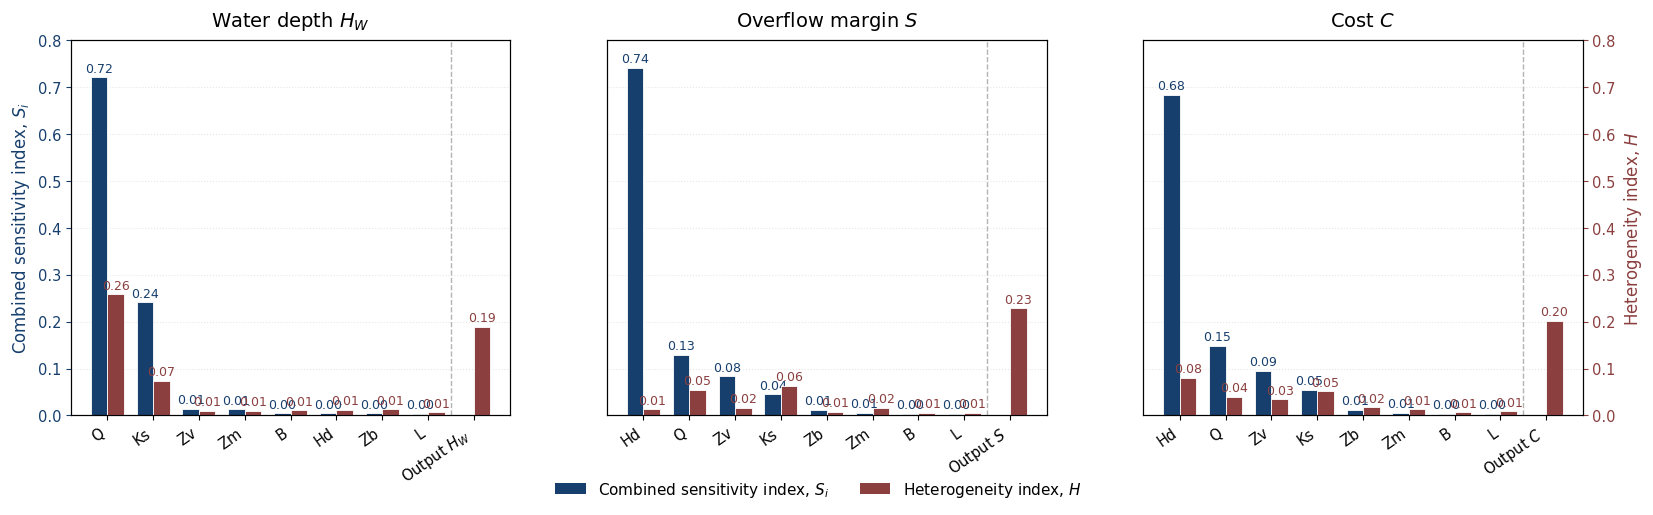

In [5]:
all_values = []
for obj in standard.values():
    all_values.extend(obj["global_si"].to_numpy(float))
    all_values.extend(obj["H"].indices.reindex(X_standard.columns).to_numpy(float))
    all_values.append(obj["H"].indices["Y"])
common_ymax = max(0.60, np.ceil((np.nanmax(all_values) + 0.05)*10)/10)
fig, axes = plt.subplots(1, 3, figsize=(16.8, 5.4))
right_axes = []
for panel_i, (ax_s, output_name) in enumerate(zip(axes, OUTPUTS)):
    global_si = standard[output_name]["global_si"]
    H = standard[output_name]["H"]
    order = global_si.sort_values(ascending=False).index.tolist()
    labels = order + [rf"Output ${{{'H_W' if output_name=='H_W' else output_name}}}$"]
    S_plot = np.r_[global_si.loc[order].to_numpy(float), np.nan]
    H_plot = np.r_[H.indices.loc[order].to_numpy(float), H.indices["Y"]]
    x = np.arange(len(labels)); width = 0.36
    ax_h = ax_s.twinx(); right_axes.append(ax_h)
    bs = ax_s.bar(x-width/2, S_plot, width, color=SI_COLOR, edgecolor="white", linewidth=0.6)
    bh = ax_h.bar(x+width/2, H_plot, width, color=H_COLOR, edgecolor="white", linewidth=0.6)
    ax_s.set_title(OUTPUT_LABELS[output_name], fontsize=14, pad=10)
    ax_s.set_ylim(0, common_ymax); ax_h.set_ylim(0, common_ymax)
    ax_s.set_xticks(x); ax_s.set_xticklabels(labels, rotation=35, ha="right", fontsize=10.5)
    ax_s.axvline(len(order)-0.5, color="0.70", linestyle="--", linewidth=1)
    ax_s.grid(axis="y", linestyle=":", alpha=0.30); ax_s.set_axisbelow(True)
    ax_s.tick_params(axis="y", colors=SI_COLOR, left=panel_i==0, labelleft=panel_i==0, labelsize=10.5)
    ax_h.tick_params(axis="y", colors=H_COLOR, right=panel_i==2, labelright=panel_i==2, labelsize=10.5)
    for b,v in zip(bs,S_plot):
        if np.isfinite(v): ax_s.text(b.get_x()+b.get_width()/2, v+common_ymax*0.014, f"{v:.2f}", ha="center", fontsize=9, color=SI_COLOR)
    for b,v in zip(bh,H_plot):
        if np.isfinite(v): ax_h.text(b.get_x()+b.get_width()/2, v+common_ymax*0.014, f"{v:.2f}", ha="center", fontsize=9, color=H_COLOR)
axes[0].set_ylabel(r"Combined sensitivity index, $S_i$", color=SI_COLOR, fontsize=12)
right_axes[-1].set_ylabel(r"Heterogeneity index, $H$", color=H_COLOR, fontsize=12)
fig.legend(handles=[Patch(facecolor=SI_COLOR, label=r"Combined sensitivity index, $S_i$"), Patch(facecolor=H_COLOR, label=r"Heterogeneity index, $H$")], loc="lower center", bbox_to_anchor=(0.5,0.025), ncol=2, frameon=False, fontsize=11)
fig.subplots_adjust(left=0.055, right=0.955, top=0.90, bottom=0.205, wspace=0.22)
plt.show()

Figure 10: Global combined sensitivity indices 𝑆𝑖 and heterogeneity indices for the flood model with (a) water depth
𝐻𝑊 , (b) overflow margin 𝑆, and (c) cost 𝐶 as outputs.

## Application-specific OK/Flood partition

In [6]:
# Representative Flood/OK analysis for Figure c4.
# IMPORTANT: reproduce the manuscript workflow exactly.
# The same 3M realization used for c3 is used here, and the abundant OK
# regime is subsampled with rng seed = BASE_SEED (not BASE_SEED + 77).

is_flood_base = Y_base["S"].to_numpy() > 0
idx_flood_base = np.flatnonzero(is_flood_base)
idx_ok_base = np.flatnonzero(~is_flood_base)

rng_base = np.random.default_rng(BASE_SEED)
idx_ok_base_used = rng_base.choice(
    idx_ok_base,
    size=min(MAX_OK, len(idx_ok_base)),
    replace=False,
)

idx_base = np.r_[idx_ok_base_used, idx_flood_base]

X_regime = X_base.iloc[idx_base].reset_index(drop=True).copy()
Y_regime = Y_base.iloc[idx_base].reset_index(drop=True).copy()

Z_regime = pd.Series(
    pd.Categorical(
        np.r_[
            np.repeat("OK", len(idx_ok_base_used)),
            np.repeat("Flood", len(idx_flood_base)),
        ],
        categories=["OK", "Flood"],
        ordered=True,
    ),
    name="Flood state",
)

representative = {}
representative_rows = []

for output_name in OUTPUTS:
    H = sd.heterogeneity_indices(
        output=Y_regime[output_name],
        inputs=X_regime,
        custom_partition=Z_regime,
    )

    key = H.indices.index[0]
    detail = H.details[key]
    representative[output_name] = H

    representative_rows.append({
        "output": output_name,
        "flood_count_generated": len(idx_flood_base),
        "ok_count_used": len(idx_ok_base_used),
        "H_flood": float(H.indices.iloc[0]),
        "flood_raw_SI_sum": float(detail.regional_sums.loc["Flood"]),
        "ok_raw_SI_sum": float(detail.regional_sums.loc["OK"]),
    })

print(
    "Representative manuscript realization: "
    f"{len(idx_flood_base):,} Flood observations; "
    f"{len(idx_ok_base_used):,} OK observations used."
)

display(pd.DataFrame(representative_rows).style.format({
    "H_flood": "{:.4f}",
    "flood_raw_SI_sum": "{:.4f}",
    "ok_raw_SI_sum": "{:.4f}",
}))

# The base 3M arrays are no longer needed after c3 and the representative
# c4 analysis have been computed.
del X_base, Y_base
gc.collect()


# Ten independent repetitions for Table 4 / robustness statistics.
# These retain the original robustness-experiment workflow, including
# the separate OK-subsampling seed seed + 77.
def one_regime_repeat(repeat):
    seed = BASE_SEED + 1000 + repeat

    X_all, Y_all = simulate_flood_model(
        N_REGIME,
        seed,
    )

    is_flood = Y_all["S"].to_numpy() > 0
    idx_flood = np.flatnonzero(is_flood)
    idx_ok = np.flatnonzero(~is_flood)

    rng = np.random.default_rng(seed + 77)
    idx_ok_used = rng.choice(
        idx_ok,
        size=min(MAX_OK, len(idx_ok)),
        replace=False,
    )

    idx = np.r_[idx_ok_used, idx_flood]

    X = X_all.iloc[idx].reset_index(drop=True)
    Y = Y_all.iloc[idx].reset_index(drop=True)

    Z = pd.Series(
        pd.Categorical(
            np.where(Y["S"].to_numpy() > 0, "Flood", "OK"),
            categories=["OK", "Flood"],
            ordered=True,
        ),
        name="Flood state",
    )

    rows = []

    for output_name in OUTPUTS:
        H = sd.heterogeneity_indices(
            output=Y[output_name],
            inputs=X,
            custom_partition=Z,
        )

        key = H.indices.index[0]
        detail = H.details[key]

        rows.append({
            "repeat": repeat,
            "seed": seed,
            "output": output_name,
            "flood_count_generated": len(idx_flood),
            "ok_count_used": len(idx_ok_used),
            "H_flood": float(H.indices.iloc[0]),
            "flood_raw_SI_sum": float(detail.regional_sums.loc["Flood"]),
            "ok_raw_SI_sum": float(detail.regional_sums.loc["OK"]),
        })

    del X_all, Y_all
    gc.collect()

    return rows


repeat_rows = []

for repeat in range(N_REPEATS):
    rows = one_regime_repeat(repeat)
    repeat_rows.extend(rows)

    print(
        f"repeat {repeat + 1}/{N_REPEATS}: "
        f"flood observations = {rows[0]['flood_count_generated']:,}"
    )

regime_results = pd.DataFrame(repeat_rows)
regime_results.to_csv(
    "flood_regime_repeats.csv",
    index=False,
)

summary = regime_results.groupby("output").agg(
    H_mean=("H_flood", "mean"),
    H_sd=("H_flood", lambda x: x.std(ddof=1)),
    H_min=("H_flood", "min"),
    H_max=("H_flood", "max"),
    flood_sum_min=("flood_raw_SI_sum", "min"),
    flood_sum_max=("flood_raw_SI_sum", "max"),
    flood_n_min=("flood_count_generated", "min"),
    flood_n_max=("flood_count_generated", "max"),
)

display(summary.style.format("{:.4f}"))


Representative manuscript realization: 871 Flood observations; 100,000 OK observations used.


,output,flood_count_generated,ok_count_used,H_flood,flood_raw_SI_sum,ok_raw_SI_sum
0,H_W,871,100000,0.6652,0.5384,1.0165
1,S,871,100000,0.7091,0.5211,1.0258
2,C,871,100000,0.3221,0.6211,1.0035


repeat 1/10: flood observations = 922
repeat 2/10: flood observations = 917
repeat 3/10: flood observations = 915
repeat 4/10: flood observations = 929
repeat 5/10: flood observations = 944
repeat 6/10: flood observations = 904
repeat 7/10: flood observations = 888
repeat 8/10: flood observations = 922
repeat 9/10: flood observations = 892
repeat 10/10: flood observations = 926


,H_mean,H_sd,H_min,H_max,flood_sum_min,flood_sum_max,flood_n_min,flood_n_max
output,,,,,,,,
C,0.3680,0.0330,0.3175,0.4247,0.5032,0.6905,888.0000,944.0000
H_W,0.6257,0.0130,0.6084,0.6442,0.4511,0.7858,888.0000,944.0000
S,0.6620,0.0303,0.6177,0.7091,0.4317,0.7090,888.0000,944.0000


## Figure 11

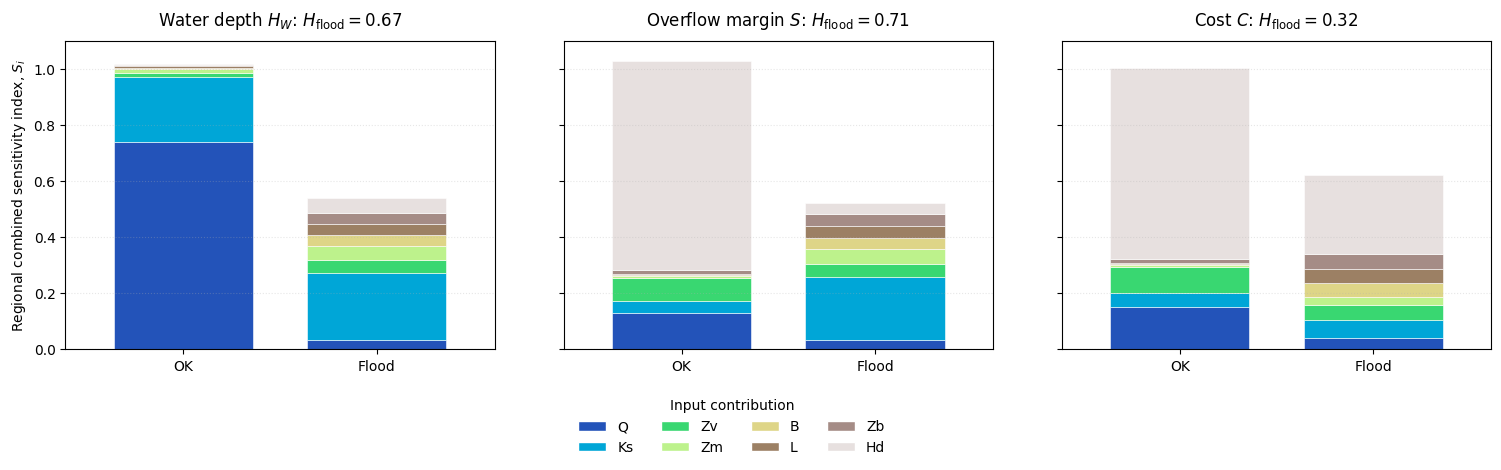

In [7]:
cmap = plt.colormaps["terrain"]
colors = {name: cmap(pos) for name,pos in zip(X_standard.columns, np.linspace(0.05,0.95,len(X_standard.columns)))}
totals = []
for output_name in OUTPUTS:
    H = representative[output_name]
    key = H.indices.index[0]
    totals.extend(H.details[key].raw_profiles.sum(axis=1).to_numpy(float))
ymax = max(1.0, np.ceil((max(totals)+0.05)*10)/10)
fig, axes = plt.subplots(1,3,figsize=(15.5,4.9),sharey=True)
for i,(ax,output_name) in enumerate(zip(axes,OUTPUTS)):
    H = representative[output_name]; key = H.indices.index[0]
    raw = H.details[key].raw_profiles.loc[["OK","Flood"]]
    raw.plot(kind="bar",stacked=True,ax=ax,color=[colors[c] for c in raw.columns],edgecolor="white",linewidth=0.4,width=0.72,legend=False)
    ax.set_title(rf"{OUTPUT_LABELS[output_name]}: $H_{{\mathrm{{flood}}}}={H.indices.iloc[0]:.2f}$",fontsize=12,pad=11)
    ax.set_xlabel(""); ax.set_ylim(0,ymax); ax.set_xticklabels(["OK","Flood"],rotation=0)
    ax.grid(axis="y",linestyle=":",alpha=0.30)
    ax.set_ylabel(r"Regional combined sensitivity index, $S_i$" if i==0 else "")
fig.legend(handles=[Patch(facecolor=colors[n],edgecolor="white",label=n) for n in X_standard.columns],title="Input contribution",loc="lower center",bbox_to_anchor=(0.5,0.01),ncol=4,frameon=False)
fig.subplots_adjust(left=0.07,right=0.99,top=0.88,bottom=0.25,wspace=0.16)
plt.show()

Figure 11: Regional combined sensitivity profiles for the application-specific partition 𝑍f lood = {OK, Flood}, shown
for (a) water depth 𝐻𝑊 , (b) overflow margin 𝑆, and (c) cost 𝐶.